In [1]:
import numpy as np
import pandas as pd
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt

In [2]:
def cfs_to_af(cfs_day):
    """
    Convert 'CFS‑days' to acre‑feet:

    acre‑ft = cfs_day * 1.9835
    """
    return cfs_day * 1.9835 


def af_to_m3(acft):
    """Convert acre‑feet to cubic metres (1 af = 1233.48 m³)."""
    return acft * 1233.48

def ft_to_m(ft):
    return ft / 3.281

## Load Storage Data

In [4]:
## Storage Data (Change in CFS/day)
BON_S = pd.read_excel("/Users/elizacohn/Desktop/Columbia River Data/BPA Data/daily/daily/BON6S_daily.xlsx")
TDA_S = pd.read_excel("/Users/elizacohn/Desktop/Columbia River Data/BPA Data/daily/daily/TDA6S_daily.xlsx")
JDA_S = pd.read_excel("/Users/elizacohn/Desktop/Columbia River Data/BPA Data/daily/daily/JDA6S_daily.xlsx")
MCN_S = pd.read_excel("/Users/elizacohn/Desktop/Columbia River Data/BPA Data/daily/daily/MCN6S_daily.xlsx")

BON_S["date"] = pd.to_datetime(BON_S["date"]).dt.normalize()
TDA_S["date"] = pd.to_datetime(TDA_S["date"]).dt.normalize()
JDA_S["date"] = pd.to_datetime(JDA_S["date"]).dt.normalize()
MCN_S["date"] = pd.to_datetime(MCN_S["date"]).dt.normalize()

In [5]:
## Calculate Relative Storage
BON_S["cumsumS"] = BON_S["S (unit:cfs)"].cumsum()
TDA_S["cumsumS"] = TDA_S["S (unit:cfs)"].cumsum()
JDA_S["cumsumS"] = JDA_S["S (unit:cfs)"].cumsum()
MCN_S["cumsumS"] = MCN_S["S (unit:cfs)"].cumsum()

# cfs‑days → acre‑feet → cubic metres
BON_S["S_m3"] = af_to_m3(cfs_to_af(BON_S["cumsumS"]))
TDA_S["S_m3"] = af_to_m3(cfs_to_af(TDA_S["cumsumS"]))
JDA_S["S_m3"] = af_to_m3(cfs_to_af(JDA_S["cumsumS"]))
MCN_S["S_m3"] = af_to_m3(cfs_to_af(MCN_S["cumsumS"]))

## Load Head Data

In [7]:
## Storage Data (Change in CFS/day)
BON_H = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/bonneville-head.csv")
TDA_H = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/dalles-head.csv")
JDA_H = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/johnday-head.csv")
MCN_H = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/mcnary-head.csv")

BON_H["Date Time"] = pd.to_datetime(BON_H["Date Time"])
TDA_H["Date Time"] = pd.to_datetime(TDA_H["Date Time"])
JDA_H["Date Time"] = pd.to_datetime(JDA_H["Date Time"])
MCN_H["Date Time"] = pd.to_datetime(MCN_H["Date Time"])

In [8]:
# Calculate net elevation (head)
BON_H["head_m"] = (BON_H["BON.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"] - BON_H["BON.Elev-Tailwater.Inst.1Hour.0.CBT-REV [ft]"])*0.3048
TDA_H["head_m"] = (TDA_H["TDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"] - TDA_H["TDA.Elev-Tailwater.Inst.1Hour.0.CBT-REV [ft]"])*0.3048
JDA_H["head_m"] = (JDA_H["JDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"] - JDA_H["JDA.Elev-Tailwater.Inst.1Hour.0.CBT-REV [ft]"])*0.3048
MCN_H["head_m"] = (MCN_H["MCN.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"] - MCN_H["MCN.Elev-Tailwater.Inst.1Hour.0.CBT-REV [ft]"])*0.3048

In [9]:
BON_daily = (BON_H.set_index("Date Time").resample("D").mean(numeric_only=True).reset_index())
TDA_daily = (TDA_H.set_index("Date Time").resample("D").mean(numeric_only=True).reset_index())
JDA_daily = (JDA_H.set_index("Date Time").resample("D").mean(numeric_only=True).reset_index())
MCN_daily = (MCN_H.set_index("Date Time").resample("D").mean(numeric_only=True).reset_index())

In [10]:
## Load special bonneville storage data
BON_S2 = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/bonneville-storage.csv")
BON_S2["Date Time"] = pd.to_datetime(BON_S2["Date Time"])

# Fit Hydraulic Head

### Merge Data 

In [132]:
BON = BON_daily.merge(BON_S2, on="Date Time", how="inner").reset_index(drop=True)
TDA = TDA_daily.merge(TDA_S, left_on="Date Time", right_on="date", how="inner").reset_index(drop=True)
JDA = JDA_daily.merge(JDA_S, left_on="Date Time", right_on="date", how="inner").reset_index(drop=True)
MCN = MCN_daily.merge(MCN_S, left_on="Date Time", right_on="date", how="inner").reset_index(drop=True)

In [171]:
print(BON["head_m"].min(), BON["head_m"].max())
print(TDA["head_m"].min(), TDA["head_m"].max())
print(JDA["head_m"].min(), JDA["head_m"].max())
print(MCN["head_m"].min(), MCN["head_m"].max())

12.42568 21.0185
20.99056 26.272363000000002
28.327223000000004 32.744791
19.74342 23.451947


In [134]:
def min_max(storage):
    min_V = storage.min()
    max_V = storage.max()

    return min_V, max_V


In [136]:
def fit_head(S, H):
    mask = S.notna() & H.notna()
    S = S[mask]
    H = H[mask]

    a, b = np.polyfit(S, H, 1)
    err = H - (a * S + b)

    rmse = np.sqrt(np.mean(err**2))
    r2 = 1 - np.sum(err**2) / np.sum((H - H.mean())**2)

    print(f"h = {a:.2f} V_norm + {b:.2f}")
    print(f"RMSE: {rmse:.3f} m")
    print(f"R2: {r2:.3f}")

    return a, b

### Bonneville

In [139]:
min_V, max_V = min_max(BON["BON.Stor.Inst.1Hour.0.CBT-COMPUTED-REV [kaf]"])

BON["S_norm"] = (BON["BON.Stor.Inst.1Hour.0.CBT-COMPUTED-REV [kaf]"] - min_V) / (max_V - min_V)

In [141]:
a, b = fit_head(BON["S_norm"], BON["head_m"])

h = 3.94 V_norm + 16.07
RMSE: 1.262 m
R2: 0.263


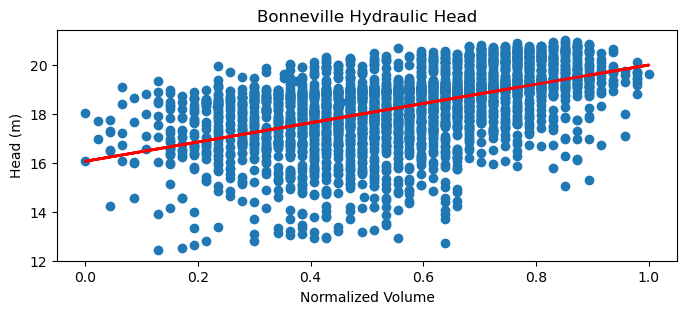

In [143]:
x = BON["S_norm"]
y_fit = a * x + b

plt.figure(figsize=(8, 3))
plt.scatter(BON["S_norm"], BON["head_m"])
plt.plot(x, y_fit, color="red", linewidth=2, label="Best fit")

plt.ylabel("Head (m)")
plt.xlabel("Normalized Volume")
plt.title("Bonneville Hydraulic Head")
plt.show()

### Dalles Dam

In [146]:
min_V, max_V = min_max(TDA["S_m3"])

TDA["S_norm"] = (TDA["S_m3"] - min_V) / (max_V - min_V)

In [148]:
a, b = fit_head(TDA["S_norm"], TDA["head_m"])

h = 3.67 V_norm + 21.78
RMSE: 0.810 m
R2: 0.194


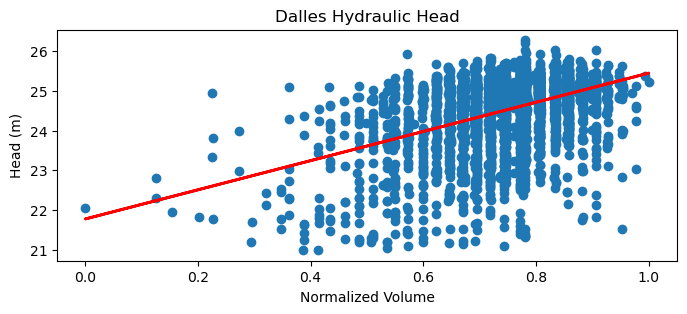

In [150]:
x = TDA["S_norm"]
y_fit = a * x + b

plt.figure(figsize=(8, 3))
plt.scatter(TDA["S_norm"], TDA["head_m"])
plt.plot(x, y_fit, color="red", linewidth=2, label="Best fit")
plt.ylabel("Head (m)")
plt.xlabel("Normalized Volume")
plt.title("Dalles Hydraulic Head")
plt.show()

### John Day Dam

In [153]:
min_V, max_V = min_max(JDA["S_m3"])

JDA["S_norm"] = (JDA["S_m3"] - min_V) / (max_V - min_V)

In [155]:
a, b = fit_head(JDA["S_norm"], JDA["head_m"])

h = 3.82 V_norm + 29.10
RMSE: 0.529 m
R2: 0.331


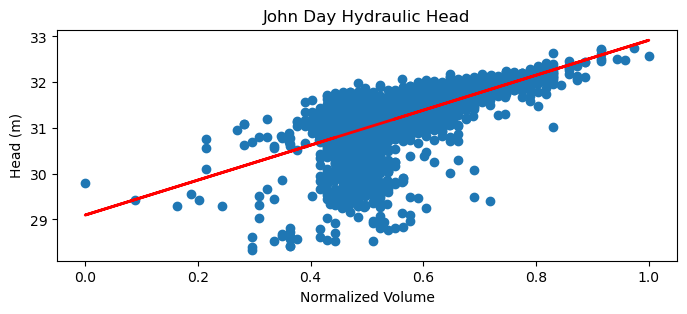

In [157]:
x = JDA["S_norm"]
y_fit = a * x + b

plt.figure(figsize=(8, 3))
plt.scatter(JDA["S_norm"], JDA["head_m"])
plt.plot(x, y_fit, color="red", linewidth=2, label="Best fit")
plt.ylabel("Head (m)")
plt.xlabel("Normalized Volume")
plt.title("John Day Hydraulic Head")
plt.show()

### McNary

In [160]:
min_V, max_V = min_max(MCN["S_m3"])

MCN["S_norm"] = (MCN["S_m3"] - min_V) / (max_V - min_V)

In [162]:
a, b = fit_head(MCN["S_norm"], MCN["head_m"])

h = 1.76 V_norm + 21.22
RMSE: 0.536 m
R2: 0.218


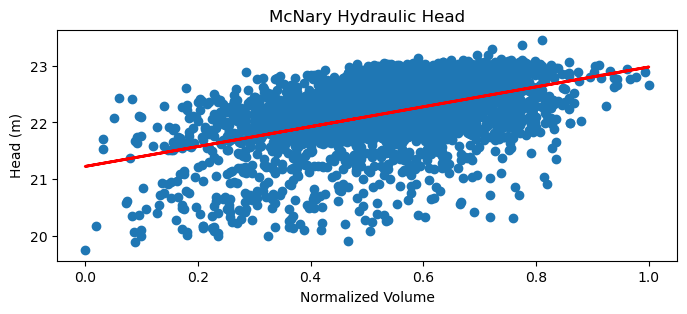

In [164]:
x = MCN["S_norm"]
y_fit = a * x + b

plt.figure(figsize=(8, 3))

plt.plot(x, y_fit, color="red", linewidth=2, label="Best fit")
plt.scatter(MCN["S_norm"], MCN["head_m"])
plt.ylabel("Head (m)")
plt.xlabel("Normalized Volume")
plt.title("McNary Hydraulic Head")
plt.show()

# Reference Volume Trajectories

In [207]:
volume_models = {}

for unit, df, forebay_col in [
    ("bon", BON, "BON.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"),
    ("tda", TDA, "TDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"),
    ("jda", JDA, "JDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"),
    ("mcn", MCN, "MCN.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"),
]:
    x = df[[forebay_col, "S_norm"]].dropna()
    a, b = np.polyfit(x[forebay_col], x["S_norm"], 1)

    volume_models[unit] = {
        "a": a,
        "b": b,
        "forebay_col": forebay_col,
    }

    print(f"{unit.upper()}: V_norm = {a:.4f} forebay + {b:.4f}")

BON: V_norm = 0.2019 forebay + -14.4221
TDA: V_norm = 0.1793 forebay + -27.7155
JDA: V_norm = 0.1330 forebay + -34.5279
MCN: V_norm = 0.2904 forebay + -97.8488


In [227]:
def apply_fit(df, unit):
    
    # Get model fit
    m = volume_models[unit]

    # Get forebay 
    col = m["forebay_col"]

    # Compute daily average
    x = df.set_index("Date Time")[col].resample("D").mean().reset_index()

    # Get date 
    d = x["Date Time"]

    # Subset data to scenario date ranges 
    x = x[d.dt.year.between(2018, 2025) & d.dt.strftime("%m-%d").between("09-07", "12-05")].dropna().copy()

    # Calculate normalized volume reference
    x["V_norm"] = (m["a"] * x[col] + m["b"]).clip(0, 1)
    x["year"] = x["Date Time"].dt.year
    x["day"] = x.groupby("year").cumcount() + 1
    return x[["Date Time", "year", "day", "V_norm"]]

BON_ref = apply_fit(BON_daily, "bon")
TDA_ref = apply_fit(TDA_daily, "tda")
JDA_ref = apply_fit(JDA_daily, "jda")
MCN_ref = apply_fit(MCN_daily, "mcn")

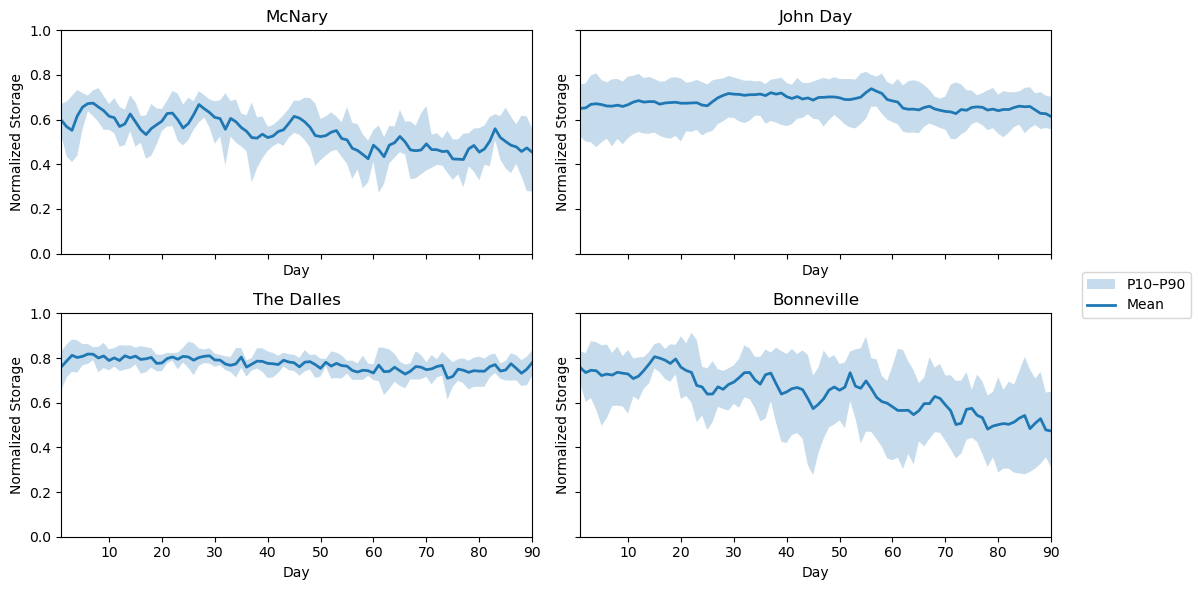

In [233]:
refs = {"McNary": MCN_ref, "John Day": JDA_ref, "The Dalles": TDA_ref, "Bonneville": BON_ref}
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, (name, df) in zip(axes.flat, refs.items()):
    g = df.groupby("day")["V_norm"]
    mean, p10, p90 = g.mean(), g.quantile(.1), g.quantile(.9)
    ax.fill_between(mean.index, p10, p90, alpha=.25, label="P10–P90")
    ax.plot(mean.index, mean, linewidth=2, label="Mean")
    ax.set(title=name, xlabel="Day", ylabel="Normalized Storage", ylim=(0, 1), xlim=(1,90))

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")
fig.tight_layout(rect=[0, 0, .9, 1])
plt.show()

In [244]:
refs = {"mcn": MCN_ref, "jda": JDA_ref, "tda": TDA_ref, "bon": BON_ref}
daily_ref = pd.DataFrame(index=range(1, 91))

for unit, df in refs.items():
    g = df.groupby("day")["V_norm"]
    daily_ref[f"{unit}_soc"] = g.mean()
    daily_ref[f"{unit}_p10"] = g.quantile(.1)
    daily_ref[f"{unit}_p90"] = g.quantile(.9)

daily_ref.index.name = "day"
daily_ref = daily_ref.reset_index()
hourly_ref = daily_ref.loc[daily_ref.index.repeat(24)].reset_index(drop=True)
hourly_ref.insert(0, "hour", range(1, 2161))

print(hourly_ref.shape)
hourly_ref

(2160, 14)


,hour,day,mcn_mean,mcn_p10,mcn_p90,jda_mean,jda_p10,jda_p90,tda_mean,tda_p10,tda_p90,bon_mean,bon_p10,bon_p90
0,1,1,0.597265,0.526203,0.670403,0.650477,0.523777,0.757743,0.760872,0.655677,0.830457,0.756672,0.684033,0.829311
1,2,1,0.597265,0.526203,0.670403,0.650477,0.523777,0.757743,0.760872,0.655677,0.830457,0.756672,0.684033,0.829311
2,3,1,0.597265,0.526203,0.670403,0.650477,0.523777,0.757743,0.760872,0.655677,0.830457,0.756672,0.684033,0.829311
3,4,1,0.597265,0.526203,0.670403,0.650477,0.523777,0.757743,0.760872,0.655677,0.830457,0.756672,0.684033,0.829311
4,5,1,0.597265,0.526203,0.670403,0.650477,0.523777,0.757743,0.760872,0.655677,0.830457,0.756672,0.684033,0.829311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,2156,90,0.454659,0.278008,0.560408,0.614034,0.556826,0.703075,0.778834,0.720224,0.834754,0.473601,0.311288,0.649122
2156,2157,90,0.454659,0.278008,0.560408,0.614034,0.556826,0.703075,0.778834,0.720224,0.834754,0.473601,0.311288,0.649122
2157,2158,90,0.454659,0.278008,0.560408,0.614034,0.556826,0.703075,0.778834,0.720224,0.834754,0.473601,0.311288,0.649122
2158,2159,90,0.454659,0.278008,0.560408,0.614034,0.556826,0.703075,0.778834,0.720224,0.834754,0.473601,0.311288,0.649122


In [248]:
hourly_ref.to_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/soc.csv", index=False)